In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import random
from tqdm import tqdm
import warnings

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


## Data Generation

In [ ]:
def make_profile(Tplat, final_T=0.0, plateau_dur=120, cooling_rate=-0.25, exp_time=500):
    """
    Create a stag cooling temperature profile DataFrame with time in minutes and temperature in °C.

    Args:
    - Tplat: Plateau temperature in °C.
    - final_T: Final temperature in °C after cooling, default to 0 °C.
    - plateau_dur: Duration of the initial isothermal plateau in minutes.
    - cooling_rate: Cooling rate in °C/min, negative stands for cooling.
    - exp_time: Total experiment time in minutes.

    Returns:
    - DataFrame with columns 't_min' and 'T_C'.
    """
    # Initial isothermal plateau at Tplat
    t1 = np.arange(0, plateau_dur + 1)
    T1 = np.full_like(t1, Tplat, dtype=float)

    # Linear cooling to final_T
    dT2 = np.abs(final_T - Tplat)
    t2_len = dT2 / abs(cooling_rate)
    t2_start = t1[-1] + 1
    t2 = np.arange(t2_start, t2_start + t2_len + 1)
    T2 = Tplat + cooling_rate * (t2 - t2[0])

    t = np.concatenate([t1, t2])
    T = np.concatenate([T1, T2])
    
    # Only add a final isothermal hold if the profile hasn't already reached the total exp_time
    if t[-1] < exp_time:
        t3_start = t[-1] + 1
        t3 = np.arange(t3_start, exp_time + 1)
        T3 = np.full_like(t3, final_T, dtype=float)
        
        t = np.concatenate([t, t3])
        T = np.concatenate([T, T3])

    return pd.DataFrame({'t_min': t.astype(int), 'T_C': T})

rng = np.random.default_rng(42)

n = 100   # Generate 100 random profiles
Tplat  = rng.uniform(30, 50, n)             # plateau temperature 35–50 °C
r1     = rng.uniform(-0.6, -0.15, n)        # cooling 0.1–0.6 °C/min
C0     = rng.uniform(0.37, 0.5, n)          # initial concentration 250–450 g/kg
plateau_dur = rng.uniform(80, 140, n)       # plateau duration 80–140 min

runs = {f"run_{i+1}": make_profile(Tplat = Tplat[i], plateau_dur = plateau_dur[i], cooling_rate = r1[i])
     for i in range(n)}

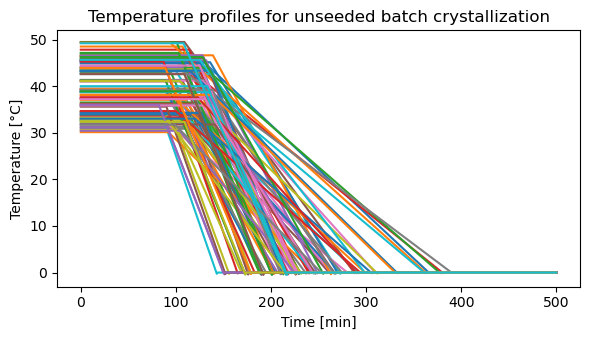

In [ ]:
# Visualize the generated temperature profiles

plt.figure(figsize=(6,3.5))
for label, df in runs.items():
    plt.plot(df['t_min'], df['T_C'], label=label)
plt.xlabel('Time [min]')
plt.ylabel('Temperature [°C]')
plt.title('Temperature profiles for unseeded batch crystallization')
plt.tight_layout()
plt.show()

In [ ]:
kv = 0.797  # -
rho = 1.263  # g/cm^3
R = 8.314  # J/mol K

kb2 = 6e3  # #(g crys/g solv)^(-beta) /(min g solv)
alfa = 2.08  # -
beta = 0.713  # -
kg = 2.73e5  # (um/min)(g solu/g solv)^(-gama_g)
Eag = 4.13e4  # J/mol
gama_g = 1.24  # -

def odefun(t, x, T):
    '''
    PBM ODE function for batch cooling using method of moments.
    '''
    mu0, mu1, mu2, mu3, conc = x

    ms = kv * rho * mu3 * 1e3  # [g cryst/kg solv]

    T_K = T + 273.15 
    Ceq = (
        -16.17
        + 1.765e-1 * T_K
        - 6.439e-4 * T_K ** 2
        + 7.915e-7 * T_K ** 3
    )  # g/g

    S = conc / Ceq
    B2 = kb2 * (max(S - 1, 0) ** alfa) * (ms ** beta)

    G = kg * np.exp(-Eag / (R * T_K)) * max(conc - Ceq, 0) ** gama_g

    dmi0dt = B2
    dmi1dt = G * mu0
    dmi2dt = 2 * G * mu1
    dmi3dt = 3 * G * mu2
    dcdt = -3 * rho * kv * G * mu2

    return [dmi0dt, dmi1dt, dmi2dt, dmi3dt, dcdt]

In [ ]:
fig, ax = plt.subplots(2, 3, figsize = (15, 8), tight_layout = True)

# randomly select 80 index from 1 to 100 for training and validation
selected = np.random.choice(np.arange(1, 101), size=80, replace=False)

# the remaining 20 index for testing
all_nums = np.arange(1, 101)
remaining = np.setdiff1d(all_nums, selected)

train_exp = list(selected)
test_exp = list(remaining)

t_input = []
T_input = []
y_true = []
initial_conditions = []

t_input_test = []
T_input_test = []
y_true_test = []
initial_conditions_test = []


for i in range(1,101):
    df_exp = runs['run_'+str(i)]
    time_eval= df_exp['t_min'].to_numpy().astype(float)
    time_span = (time_eval[0], time_eval[-1])
    temperature = df_exp['T_C'].to_numpy()
    dx0 = np.array([100.,0.,0.,0.,C0[i-1]])  # Initial conditions, minimal seeding

    # For ode solver with time-dependent temperature
    T_interp = interp1d(time_eval, temperature, kind='linear', fill_value="extrapolate")

    def odefun_interp(t, x):
        T_current = T_interp(t)
        return odefun(t, x, T_current)
    
    sol = solve_ivp(odefun_interp, time_span, dx0, t_eval=time_eval, method="LSODA")
    T_K = temperature + 273.15
    Ceq = (
        -16.17
        + 1.765e-1 * T_K
        - 6.439e-4 * T_K ** 2
        + 7.915e-7 * T_K ** 3
    )
    
    time_sol = sol.t - np.min(sol.t)
    mu0_sol, mu1_sol, mu2_sol, mu3_sol, conc_sol = sol.y

    mu = sol.y[:4,:]

    # Add gaussian noise
    conc_std = np.std(conc_sol)
    mu_stds = np.std(mu, axis=1, keepdims=True)
    conc_noise = np.random.normal(loc=0.0, scale=0.1*conc_std, size=conc_sol.shape)
    mu_noise = np.random.normal(loc=0.0, scale=0.1*mu_stds, size=mu.shape)

    conc_noisy = conc_sol + conc_noise
    mu_noisy = mu + mu_noise

    sol = np.vstack((mu_noisy,conc_noisy))

    # For plotting reference only
    S = conc_sol / Ceq
    # Visualize noisy data
    ax[0, 0].plot(time_sol, conc_noisy, '--')
    ax[0, 1].plot(time_sol, mu_noisy[0,:], '--')
    ax[0, 2].plot(time_sol, S, '--')
    ax[1, 0].plot(time_sol, mu_noisy[1,:], '--')
    ax[1, 1].plot(time_sol, mu_noisy[2,:], '--')
    ax[1, 2].plot(time_sol, mu_noisy[3,:], '--')

    if i in train_exp:
        t_input.append(time_sol.reshape(-1,1))
        T_input.append(temperature.reshape(-1,1))
        initial_conditions.append(dx0)
        y_true.append(sol.T)

    elif i in test_exp:
        t_input_test.append(time_sol.reshape(-1,1))
        T_input_test.append(temperature.reshape(-1,1))
        initial_conditions_test.append(dx0)
        y_true_test.append(sol.T)

ax[0,0].legend(['run_1','run_2','run_3'])
ax[0,0].set_title('concentration')
ax[0,1].set_title('mu0')
ax[0,2].set_title('S')
ax[1,0].set_title('mu1')
ax[1,1].set_title('mu2')
ax[1,2].set_title('mu3')

# Prepare data into the correct shape
t_input = np.vstack(t_input)

y_true = np.vstack(y_true)
y_scale = np.max(y_true, axis = 0)  # Use max training scale for normalization
y_true = y_true/y_scale    
y_true = y_true.reshape(len(train_exp), -1, y_true.shape[1])
initial_conditions = np.vstack(initial_conditions)
initial_conditions = initial_conditions/y_scale

T_input = np.vstack(T_input)
T_input = T_input.reshape(len(train_exp), -1, 1)

t_input_test = np.vstack(t_input_test)
y_true_test = np.vstack(y_true_test)
y_true_test = y_true_test/y_scale
y_true_test = y_true_test.reshape(len(test_exp), -1, y_true_test.shape[1])
initial_conditions_test = np.vstack(initial_conditions_test)
initial_conditions_test = initial_conditions_test/y_scale

T_input_test = np.vstack(T_input_test)
T_input_test = T_input_test.reshape(len(test_exp), -1, 1)

## PIRNN Model

In [ ]:
relu = torch.nn.functional.relu

class PBM(nn.Module):
    '''
    PBM model using method of moments for batch cooling.
    5 state variables: mu0, mu1, mu2, mu3, C
    6 parameters to be learned: kb2, alfa, beta, kg, Eag, gama_g
    '''

    def __init__(self):
        super().__init__()

        self.R = R
        self.rho = rho
        self.kv = kv
        self.y_scale = y_scale

        # Initialize all learnable physical parameters to 1, avoiding bias
        self.kb2 = nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.alfa = nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.beta = nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.kg = nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.Eag = nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.gama_g = nn.Parameter(torch.tensor(1, dtype=torch.float32))

    def Ceq(self, T_K):
        return (
                -16.17
                + 1.765e-1 * T_K
                - 6.439e-4 * T_K ** 2
                + 7.915e-7 * T_K ** 3
                )

    def forward(self, t, x, T):
        '''
        The ODE-calculated time derivatives of the state variables. The derivatives are scaled back to original scale to ensure correct physical meaning.
        '''
        mu0, mu1, mu2, mu3, C = x[...,0], x[...,1], x[...,2], x[...,3], x[...,4]
        mu0 = mu0 * self.y_scale[0]
        mu1 = mu1 * self.y_scale[1]
        mu2 = mu2 * self.y_scale[2]
        mu3 = mu3 * self.y_scale[3]
        C = C * self.y_scale[4]

        T_K = T + 273.15
        Ceq_val = self.Ceq(T_K)

        S = C/torch.clamp(Ceq_val, min=1e-16) # avoid division by zero
        ms = self.kv * self.rho * mu3 * 1e3

        B2 = torch.exp(self.kb2) * relu(S - 1.0).pow(torch.exp(self.alfa)) * ms.pow(torch.exp(self.beta))

        G = torch.exp(self.kg) * torch.exp(-(torch.exp(self.Eag) / (self.R * T_K))) * relu(C - Ceq_val).pow(torch.exp(self.gama_g))
        
        # Calculate derivatives and scale back to normalized scale to match with finite differences
        dmu0 = (B2)/self.y_scale[0]
        dmu1 = G * mu0/self.y_scale[1]
        dmu2 = 2 * G * mu1/self.y_scale[2]
        dmu3 = 3 * G * mu2/self.y_scale[3]
        dC = -3 * self.rho * self.kv * G * mu2/self.y_scale[4]

        return torch.stack([dmu0, dmu1, dmu2, dmu3, dC], dim=-1)

In [ ]:
class PIRNN(nn.Module):
    def __init__(self, n_state=5, n_ctrl=1, hidden=64, layers=2, delta=1, dropout=0.2):
        '''
        Physics-Informed RNN for learning state evolution with physical constraints.

        param n_state: Number of state variables
        param n_ctrl: Number of control inputs
        param hidden: Number of hidden units in LSTM
        param layers: Number of LSTM layers
        param delta: Time step size
        param dropout: Dropout rate for regularization
        '''
        super().__init__()
        self.n_state = n_state  
        self.n_ctrl  = n_ctrl
        self.delta = delta
        
        self.dropout = nn.Dropout(dropout)
        
        self.lstm = nn.LSTM(input_size=n_state+n_ctrl,
                            hidden_size=hidden,
                            num_layers=layers,
                            batch_first=True,
                            dropout=dropout if layers > 1 else 0)
        
        self.batch_norm = nn.BatchNorm1d(hidden)
        self.fc = nn.Linear(hidden, n_state)
        
        # Learnable noise scale parameter used to weight the MSE and Huber data loss
        self.noise_scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, x0, T_seq):
        '''
        Forward pass of the Physics-Informed RNN.
        
        param x0: Initial state tensor
        param T_seq: Sequence of control inputs (e.g., temperature)
        '''
        _, N, _ = T_seq.shape
        x0 = x0.unsqueeze(1).expand(-1, N, -1)
        lstm_in = torch.cat([x0, T_seq], dim=-1)
        
        out, _ = self.lstm(lstm_in)
        
        # Apply batch normalization and dropout
        out_reshaped = out.reshape(-1, out.shape[-1])
        out_norm = self.batch_norm(out_reshaped)
        out_norm = out_norm.reshape(out.shape)
        out_norm = self.dropout(out_norm)
        
        # Full connection to output layer
        x_hat = self.fc(out_norm)
        # Ensure outputs are positive
        return torch.nn.functional.softplus(x_hat)


def lossData(pred, target, noise_scale=None):
    """
    Data fitting loss

    Args:
    - pred: Predicted state variables from the model
    - target: Targeted observed state variable values
    - noise_scale: Noise scale parameter learned by PRINN to weight losses
    """
    mse = nn.MSELoss()(pred, target)
    
    huber_loss = nn.HuberLoss(delta=0.1)(pred, target)
    
    if noise_scale is not None:
        weight = torch.sigmoid(-noise_scale)  # Less weight when noise is high
        return weight * mse + (1 - weight) * huber_loss
    else:
        return 0.7 * mse + 0.3 * huber_loss

def lossPhysics(pred, T_seq, pbm, dt):
    """
    Physics constraint loss
    
    Args:
    - pred: Predicted state variables from the model
    - T_seq: Corresponding control input temperature sequences
    - pbm: PBM model instance to compute physical derivatives
    - dt: Time step size
    """

    # Finite difference approximation of time derivatives
    dx = (pred[:, 2:] - pred[:, :-2]) / (2*dt)
    x_mid = pred[:, 1:-1] # Use midpoints for derivative comparison
    T_mid = T_seq[:, 1:-1, 0]
    pbm_dx = pbm(None, x_mid, T_mid)
    return nn.MSELoss()(dx, pbm_dx)

def lossSmooth(pred):
    """
    Smoothness loss to penalize noisy predictions

    Args:
    - pred: Predicted state variables from the model
    """
    
    # Second-order differences to penalize rapid changes
    d2x = pred[:, 2:] - 2*pred[:, 1:-1] + pred[:, :-2]
    return torch.mean(d2x**2)

In [ ]:
torch.manual_seed(42)

x0 = torch.tensor(initial_conditions, dtype=torch.float32).to(device)
T_data = torch.tensor(T_input, dtype=torch.float32).to(device)
y_data = torch.tensor(y_true, dtype=torch.float32).to(device)

x0_test = torch.tensor(initial_conditions_test, dtype=torch.float32).to(device)
T_data_test = torch.tensor(T_input_test, dtype=torch.float32).to(device)
y_data_test = torch.tensor(y_true_test, dtype=torch.float32).to(device)

# Split training and validation sets
num_total_runs = x0.shape[0]
val_size = 20  # Use 20 runs for validation
train_size = num_total_runs - val_size

shuffled_indices = torch.randperm(num_total_runs)
train_indices = shuffled_indices[:train_size]
val_indices = shuffled_indices[train_size:]

x0_train = x0[train_indices]
T_data_train = T_data[train_indices]
y_data_train = y_data[train_indices]

x0_val = x0[val_indices]
T_data_val = T_data[val_indices]
y_data_val = y_data[val_indices]

print(f"Training set size: {x0_train.shape[0]} runs")
print(f"Validation set size: {x0_val.shape[0]} runs")
print(f"Test set size: {x0_test.shape[0]} runs")

Training set size: 60 runs
Validation set size: 20 runs
Test set size: 20 runs


In [ ]:
def evaluate_model(model, pbm, x0, T_data, y_data):
    '''  
    Evaluate the model on given data and compute losses.

    Args:
    - model: The trained PIRNN model
    - pbm: The PBM model instance for physics loss
    - x0: Initial state tensor
    - T_data: Corresponding control input temperature sequences
    - y_data: Targeted observed state variable values

    Returns:
    - loss: Loss value, can be edited to include/exclude components
    - lX: Data fitting loss
    - lG: Physics constraint loss
    - lSmooth: Smoothness loss
    '''
    model.eval()
    with torch.no_grad():
        pred = model(x0, T_data)
        lX = lossData(pred, y_data, model.noise_scale)
        lG = lossPhysics(pred, T_data, pbm, model.delta)
        lSmooth = lossSmooth(pred)
        
        loss = lX #+ lG + lSmooth
    return loss.item(), lX.item(), lG.item(), lSmooth.item()

def set_seed(seed):
    '''  
    Set random seed for reproducibility.
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

pbm_ground_truth = {
    'kb2': 6e3,
    'alfa': 2.08,
    'beta': 0.713,
    'kg': 2.73e5,
    'Eag': 4.13e4,
    'gama_g': 1.24,
}

def calculate_param_error(pbm, ground_truth, device):
    '''
    Calculate the RMSRE between predicted and ground truth PBM parameters.
    
    Args:
    - pbm: The PBM model instance with learned parameters
    - ground_truth: Dictionary of ground truth parameter values
    - device: Device to perform calculations on
    '''
    params_pred = torch.exp(torch.tensor([
        pbm.kb2.item(), pbm.alfa.item(), pbm.beta.item(),
        pbm.kg.item(), pbm.Eag.item(), pbm.gama_g.item()
    ], device=device))

    params_true = torch.tensor([
        ground_truth['kb2'], ground_truth['alfa'], ground_truth['beta'],
        ground_truth['kg'], ground_truth['Eag'], ground_truth['gama_g']
    ], device=device)

    relative_errors = (params_pred - params_true) / params_true
    rmsre = torch.sqrt(torch.mean(relative_errors**2))
    return rmsre.item()

In [ ]:
epochs = 400000  # Training epochs
data_size_sweep = [5, 10, 20, 40, 50, 60]  # Number of training runs to sweep over
results = []
loss_history = []
best_val_models = {}

for size in data_size_sweep:
    x0_subset = x0_train[:size]
    T_data_subset = T_data_train[:size]
    y_data_subset = y_data_train[:size]

    print("-" * 50)
    print(f"TRAINING CONFIG: Data Size = {size}")
    print("-" * 50)

    # Re-initialize model and PBM for each data size
    set_seed(3407) 
        
    pbm = PBM().to(device)
    model = PIRNN(dropout=0.2).to(device)

    opt = torch.optim.Adam(list(model.parameters()) + list(pbm.parameters()), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-7) 
    
    best_val_loss = float('inf')
    best_val_index = 0
    best_val_model = None

    for epoch in range(epochs):
        model.train()
        
        opt.zero_grad() 
        
        pred = model(x0_subset, T_data_subset)
        
        # Compute all loss components
        lX = lossData(pred, y_data_subset, model.noise_scale)
        lG = lossPhysics(pred, T_data_subset, pbm, model.delta)
        lSmooth = lossSmooth(pred)
        loss = lX + lSmooth + 1e1*lG

        loss.backward()
        opt.step()
        scheduler.step() 

        if epoch % 500 == 0 or epoch == epochs - 1:
            # Evaluate on validation and test sets and record every 500 epochs
            val_loss, val_lX, val_lG, val_lSmooth = evaluate_model(model, pbm, x0_val, T_data_val, y_data_val)
            test_loss, test_lX, test_lG, test_lSmooth = evaluate_model(model, pbm, x0_test, T_data_test, y_data_test) 
            param_error = calculate_param_error(pbm, pbm_ground_truth, device)

            loss_history.append({
                'data_size': size,
                'epoch': epoch,
                'train_loss': loss.item(), 'train_lX': lX.item(), 'train_lG': lG.item(),
                'train_lSmooth': lSmooth.item(),
                'val_loss': val_loss, 'val_lX': val_lX, 'val_lG': val_lG,
                'val_lSmooth': val_lSmooth,
                'test_loss': test_loss, 'test_lX': test_lX, 'test_lG': test_lG,
                'test_lSmooth': test_lSmooth,
                'pbm_kb2': pbm.kb2.item(),
                'pbm_alfa': pbm.alfa.item(),
                'pbm_beta': pbm.beta.item(),
                'pbm_kg': pbm.kg.item(),
                'pbm_Eag': pbm.Eag.item(),
                'pbm_gama_g': pbm.gama_g.item(),
                'param_error_rmsre': param_error,
                'noise_scale': model.noise_scale.item(),
            })
            
            if val_loss < best_val_loss:
                # Identify best validation loss and epoch and save the model
                best_val_loss = val_loss
                best_val_index = epoch 
                best_val_model = {
                    'model_state_dict': model.state_dict(),
                    'pbm_state_dict': pbm.state_dict()
                }

            if epoch % 2000 == 0 or epoch == epochs - 1:
                print(f'Epoch {epoch:6d}: Train Loss={loss.item():.4e} (lX={lX:.4e}, lG={lG:.4e}, lS={lSmooth:.4e}) | Val Loss={val_loss:.4e} | Test Loss={test_loss:.4e} | LR={opt.param_groups[0]["lr"]:.2e}')
    
    last_log_entry = loss_history[-1]
    print("\nTraining finished.")
    print(f"Final Val Loss: {last_log_entry['val_loss']:.4e} (lX={last_log_entry['val_lX']:.4e}, lG={last_log_entry['val_lG']:.4e})")
    print(f"Final Test Loss: {last_log_entry['test_loss']:.4e} (lX={last_log_entry['test_lX']:.4e}, lG={last_log_entry['test_lG']:.4e})")
    print(f"Final PBM Params: kb2={last_log_entry['pbm_kb2']:.4f}, alfa={last_log_entry['pbm_alfa']:.4f}, beta={last_log_entry['pbm_beta']:.4f}, "
          f"kg={last_log_entry['pbm_kg']:.4f}, Eag={last_log_entry['pbm_Eag']:.4f}, gama_g={last_log_entry['pbm_gama_g']:.4f}")
    print(f"Final Parameter Error (RMSRE): {last_log_entry['param_error_rmsre']:.4e}")
            
    results.append({
        'data_size': size,
        'epochs': epochs,
        'final_val_loss': last_log_entry['val_loss'],
        'final_test_loss': last_log_entry['test_loss'],
        'best_val_loss': best_val_loss,
        'best_val_epoch': best_val_index,
    })

    best_val_models[size] = best_val_model

# Uncomment to save best validation models for each data size
# torch.save(best_val_models, 'best_val_models.pth')

In [ ]:
# Visualization of loss history for different data sizes
loss_history_df = pd.DataFrame(loss_history)

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True)
axes = axes.flatten()

unique_data_sizes = sorted(loss_history_df['data_size'].unique())

min_param = loss_history_df['param_error_rmsre'].min()
max_param = loss_history_df['param_error_rmsre'].max()

for i, size in enumerate(unique_data_sizes):
    ax = axes[i]
    subset = loss_history_df[loss_history_df['data_size'] == size]
    
    p1, = ax.plot(subset['epoch'], subset['val_loss'], '--', label='Validation Error', alpha=0.9, color='darkorange')
    p2, = ax.plot(subset['epoch'], subset['test_loss'], ':', label='Test Error', alpha=0.9, color='royalblue')

    ax.set_title(f'Data Size: {size} Runs', fontsize=15, fontweight='bold')
    ax.set_xlabel('Training Epoch', fontsize=12)
    ax.set_yscale('log')
    
    if i % 3 == 0:
        ax.set_ylabel('MSE Error', fontsize=12, color='black')
        ax.tick_params(axis='y', labelcolor='black')
    else:
        ax.tick_params(axis='y', labelleft=False)
        
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    ax2 = ax.twinx()
    p3, = ax2.plot(subset['epoch'], subset['param_error_rmsre'], '-', label='Param. Error (RMSRE)', alpha=0.9, color='crimson')
    
    ax2.set_ylim(min_param * 0.9, max_param * 1.1)

    if i % 3 == 2:
        ax2.set_ylabel('Parameter Error (RMSRE)', fontsize=12, color='crimson')
        ax2.tick_params(axis='y', labelcolor='crimson')
    else:
        ax2.tick_params(axis='y', labelright=False)
    ax2.grid(False)

    plots = [p1, p2, p3]
    ax.legend(plots, [p.get_label() for p in plots], loc='upper right')

    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

for j in range(len(unique_data_sizes), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Error Metrics vs. Training Epoch for Different Data Sizes', fontsize=22, fontweight='bold')

fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [ ]:
def odefun_pred(t, x, T_func, params):
    '''
    PBM ODE function for batch cooling using method of moments with given parameters.

    Args:
    - t: Time
    - x: State variables [mu0, mu1, mu2, mu3, conc]
    - T_func: Function to get temperature at time t
    - params: PBM parameters [log(kb2), log(alfa), log(beta), log(kg), log(Eag), log(gama_g)]
    '''
    mu0, mu1, mu2, mu3, conc = x
    kb2, alfa, beta, kg, Eag, gama_g = np.exp(params)

    ms = kv * rho * mu3 * 1e3

    T = T_func(t)

    T_K = T + 273.15 
    Ceq = (
        -16.17
        + 1.765e-1 * T_K
        - 6.439e-4 * T_K ** 2
        + 7.915e-7 * T_K ** 3
    )  # g/g

    S = conc / Ceq

    B2 = kb2 * (max(S - 1, 0) ** alfa) * (ms ** beta)

    G = kg * np.exp(-Eag / (R * T_K)) * max(conc - Ceq, 0) ** gama_g

    dmi0dt = B2
    dmi1dt = G * mu0
    dmi2dt = 2 * G * mu1
    dmi3dt = 3 * G * mu2
    dcdt = -3 * rho * kv * G * mu2

    return [dmi0dt, dmi1dt, dmi2dt, dmi3dt, dcdt]

pbm_param_names = ['pbm_kb2', 'pbm_alfa', 'pbm_beta', 'pbm_kg', 'pbm_Eag', 'pbm_gama_g']
target_epochs = list(np.arange(5000, 400000, 3000, dtype = int))  # Re-evaluate every 3000 epochs for time efficiency
df_to_evaluate = loss_history_df[loss_history_df['epoch'].isin(target_epochs)].copy()
print(f"Found {len(df_to_evaluate)} parameter sets to re-evaluate across {len(target_epochs)} target epochs.")

re_eval_results = []

for index, row in tqdm(df_to_evaluate.iterrows(), total = df_to_evaluate.shape[0]):
    
    params = row[pbm_param_names].values.astype(float)
    total_mse_for_row = 0
    
    for i in range(len(test_exp)):
        time_eval = t_input_test[:501].flatten()
        time_span = (time_eval[0], time_eval[-1])
        y0 = dx0 = np.array([100.,0.,0.,0.,C0[test_exp[i]]])
        T_profile = T_input_test[i].flatten()
        y_true_profile = (y_true_test[i] *y_scale).T
        
        T_func = interp1d(time_eval, T_profile, kind='linear', fill_value="extrapolate")
        
        # Suppress warnings during ODE solving to avoid unphysical learned parameters
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            warnings.simplefilter("ignore", UserWarning)
            sol = solve_ivp(
                fun=odefun_pred,
                t_span=time_span,
                y0=y0,
                t_eval=time_eval,
                args=(T_func, params),
                method='LSODA'
            )
        
        # Scale the re-evaluated ODE solution for comparison
        y_pred = (sol.y.T / y_scale).T
        if y_pred.shape == y_true_profile.shape:
            mse = np.mean((y_pred - (y_true_profile.T / y_scale).T)**2)
            total_mse_for_row += mse
        else:
            print('shape mismatch')
            total_mse_for_row += np.nan

    re_eval_results.append({
        'data_size': row['data_size'],
        'epoch': row['epoch'],
        're_eval_test_mse': total_mse_for_row / len(test_exp)
    })

Found 792 parameter sets to re-evaluate across 132 target epochs.


100%|██████████| 792/792 [03:21<00:00,  3.93it/s]


In [ ]:
re_eval_results_df = pd.DataFrame(re_eval_results)

# Merge re-evaluation ODE results with loss history for plotting
combined_df = pd.merge(
    loss_history_df,
    re_eval_results_df,
    on=['data_size', 'epoch'],
    how='left'
)
data_sizes = [5, 10, 20, 40, 50, 60]

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharey = True)
axes = axes.flatten()

for i, size in enumerate(data_sizes):
    ax = axes[i]
    subset = combined_df[combined_df['data_size'] == size]

    p1, = ax.plot(subset['epoch'], subset['val_loss'], '--', label='Validation Error', color='darkorange')
    p2, = ax.plot(subset['epoch'], subset['test_loss'], ':', label='Test Error', color='royalblue')
    ax.set_yscale('log')
    ax.set_title(f'Data Size: {size} Runs', fontsize=16, fontweight='bold')
    ax.set_xlabel('Training Epoch', fontsize=12)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    ax2 = ax.twinx()
    ax3 = ax.twinx()

    p3, = ax2.plot(subset['epoch'], subset['param_error_rmsre'], '-', label='Parameters Error', color='crimson')
    ax2.grid(False)

    ax3.spines['right'].set_position(('outward', 60))
    p4, = ax3.plot(subset['epoch'].loc[subset['re_eval_test_mse'].dropna().index], subset['re_eval_test_mse'].dropna(), '-', markevery=0.1, markersize=5, label='Re-evaluated Test Error', color='green')
    ax3.set_yscale('log')
    ax3.grid(False)

    if i % 3 == 0: 
        ax.set_ylabel('Network MSE', fontsize=12, color='black')
        ax.tick_params(axis='y', labelcolor='black')
    else:
        ax.tick_params(axis='y', labelleft=False)

    if i % 3 == 2:
        ax2.set_ylabel('Parameter RMRSE', fontsize=12, color='crimson')
        ax2.tick_params(axis='y', labelcolor='crimson')
        ax3.set_ylabel('Re-evaluated Test MSE', fontsize=12, color='green')
        ax3.tick_params(axis='y', labelcolor='green')
    else:
        ax2.tick_params(axis='y', labelright=False)
        ax3.tick_params(axis='y', labelright=False)

    plots = [p1, p2, p3, p4]
    ax.legend(plots, [p.get_label() for p in plots], loc='upper right')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

fig.suptitle('Error Metrics vs. Training Epoch for Different Data Sizes', fontsize=22, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# Visualize predictions of the best model on the test set for a specific data size

model.load_state_dict(best_val_models[60]['model_state_dict']) # Load best model for data size 60, change as needed
pbm.load_state_dict(best_val_models[60]['pbm_state_dict']) # Load corresponding learned PBM parameters

model.eval()
with torch.no_grad():
    pred_test = model(x0_test, T_data_test)
    lX_test = lossData(pred_test, y_data_test)                     # data
    lG_test = lossPhysics(pred_test, T_data_test, pbm, model.delta)     # physics
    loss_test = lX_test + lG_test                                # total test loss, change as needed
    print(f'Test Loss: {loss_test.item():.4e}  '
          f'lX={lX_test.item():.4e}  lG={lG_test.item():.4e}')

fig, ax = plt.subplots(2, 3, figsize=(15, 6), tight_layout = True)

# -1 stands for the last test run, change as needed
ax[0, 0].plot(pred_test[-1,:,0].detach().cpu().numpy(),  '--', label='PIRNN Prediction')
ax[0, 0].plot(y_data_test[-1,:,0].detach().cpu().numpy(), label='Testing data', alpha=0.5)
ax[0, 0].plot(y_pred.T[:,0],':', label='Re-evaluated ODE')
ax[0, 0].set_title('mu0')
ax[0, 0].legend()

ax[0, 1].plot(pred_test[-1,:,1].detach().cpu().numpy(),  '--', label='Predicted mu1')
ax[0, 1].plot(y_data_test[-1,:,1].detach().cpu().numpy(), label='True mu1', alpha=0.5)
ax[0, 1].plot(y_pred.T[:,1], ':',label='Re-evaluated ODE')
ax[0, 1].set_title('mu1')

ax[0, 2].plot(pred_test[-1,:,2].detach().cpu().numpy(),  '--', label='Predicted mu2')
ax[0, 2].plot(y_data_test[-1,:,2].detach().cpu().numpy(), label='True mu2', alpha=0.5)
ax[0, 2].plot(y_pred.T[:,2], ':',label='Re-evaluated ODE')

ax[0, 2].set_title('mu2')

ax[1, 0].plot(pred_test[-1,:,3].detach().cpu().numpy(),  '--', label='Predicted mu3')
ax[1, 0].plot(y_data_test[-1,:,3].detach().cpu().numpy(), label='True mu3', alpha=0.5)
ax[1, 0].plot(y_pred.T[:,3], ':',label='Re-evaluated ODE')

ax[1, 0].set_title('mu3')

ax[1, 1].plot(pred_test[-1,:,4].detach().cpu().numpy(),  '--', label='Predicted C')
ax[1, 1].plot(y_data_test[-1,:,4].detach().cpu().numpy(), label='True C', alpha=0.5)
ax[1, 1].plot(y_pred.T[:,4], ':',label='Re-evaluated ODE')
ax[1, 1].set_title('Concentration')

ax[1, 2].plot(T_data_test[-1,:,0].detach().cpu().numpy(), label='Temperature (Celsius)')
ax[1, 2].set_title('Temperature (Celsius)', fontsize=14)
ax[1, 2].set_xlabel('Time (min)')

In [ ]:
# Visualize predictions of the best model on the training set for a specific experiment
fig, ax = plt.subplots(2, 3, figsize=(15, 8), tight_layout=True)

exp_no = 4  # Expieriment number in the training set to visualize, change as needed
ax[0, 0].plot(y_data_train[exp_no,:,0].detach().cpu().numpy(), label='Training data', alpha=1)
ax[0, 0].plot(pred[exp_no,:,0].detach().cpu().numpy(),  '--', label='Predicted value')
ax[0, 0].set_title('mu0', fontsize=14)
ax[0, 0].legend()

ax[0, 1].plot(y_data_train[exp_no,:,1].detach().cpu().numpy(), label='Training data', alpha=1)
ax[0, 1].plot(pred[exp_no,:,1].detach().cpu().numpy(),  '--', label='Predicted value')
ax[0, 1].set_title('mu1', fontsize=14)

ax[0, 2].plot(y_data_train[exp_no,:,2].detach().cpu().numpy(), label='Training data', alpha=1)
ax[0, 2].plot(pred[exp_no,:,2].detach().cpu().numpy(),  '--', label='Predicted value')
ax[0, 2].set_title('mu2', fontsize=14)

ax[1, 0].plot(y_data_train[exp_no,:,3].detach().cpu().numpy(), label='Training data', alpha=1)
ax[1, 0].plot(pred[exp_no,:,3].detach().cpu().numpy(),  '--', label='Predicted value')
ax[1, 0].set_title('mu3', fontsize=14)
ax[1, 0].set_xlabel('Time (min)')

ax[1, 1].plot(y_data_train[exp_no,:,4].detach().cpu().numpy(), label='Training data', alpha=1)
ax[1, 1].plot(pred[exp_no,:,4].detach().cpu().numpy(),  '--', label='Predicted value')
ax[1, 1].set_title('Concentration', fontsize=14)
ax[1, 1].set_xlabel('Time (min)')

ax[1, 2].plot(T_data[exp_no,:,0].detach().cpu().numpy(), label='Temperature (Celsius)')
ax[1, 2].set_title('Temperature (Celsius)', fontsize=14)
ax[1, 2].set_xlabel('Time (min)')

fig.suptitle('Experiment ' + str(train_exp[exp_no]), fontsize=16)

## Model Convergence

In [ ]:
# Verify physics consistency on training data

dx = (pred[:, 2:] - pred[:, :-2]) / (2*1)
x_mid = pred[:, 1:-1]
x_true_mid = y_data_train[:, 1:-1]
T_mid = T_data_train[:, 1:-1, 0]

mu0, mu1, mu2, mu3, C = x_mid[...,0], x_mid[...,1], x_mid[...,2], x_mid[...,3], x_mid[...,4]

mu0 = mu0 * pbm.y_scale[0]
mu1 = mu1 * pbm.y_scale[1]
mu2 = mu2 * pbm.y_scale[2]
mu3 = mu3 * pbm.y_scale[3]
C = C * pbm.y_scale[4]
T_K = T_mid + 273.15
Ceq_val = pbm.Ceq(T_K)

S = C/torch.clamp(Ceq_val, min=1e-16)
ms = pbm.kv * pbm.rho * mu3 * 1e3

B2 = torch.exp(pbm.kb2) * relu(S - 1.0).pow(torch.exp(pbm.alfa)) * ms.pow(torch.exp(pbm.beta))

G = torch.exp(pbm.kg) * torch.exp(-(torch.exp(pbm.Eag) / (pbm.R * T_K))) * relu(C - Ceq_val).pow(torch.exp(pbm.gama_g))

dmu0 = (B2)/pbm.y_scale[0]
dmu1 = G * mu0/pbm.y_scale[1]
dmu2 = 2 * G * mu1/pbm.y_scale[2]
dmu3 = 3 * G * mu2/pbm.y_scale[3]
dC = -3 * pbm.rho * pbm.kv * G * mu2/pbm.y_scale[4]

pred_dx = torch.stack([dmu0, dmu1, dmu2, dmu3, dC], dim=-1)

In [ ]:
# Parity plot of predicted PBM calculated derivatives vs finite difference derivatives
fig, axs = plt.subplots()
for i in range(5):
    axs.scatter(pred_dx[:, :, i].detach().cpu().numpy(), 
                dx[:, :, i].detach().cpu().numpy())

axs.legend(['mu0', 'mu1', 'mu2', 'mu3', 'C'])

axs.set_xlabel('RHS model')
axs.set_ylabel('Finite difference model')
lims = [
    np.min([axs.get_xlim(), axs.get_ylim()]),  # min of both axes
    np.max([axs.get_xlim(), axs.get_ylim()]),  # max of both axes
]
axs.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
axs.set_title('Predicted states, Predicted RHS model', fontsize=14)